Define, train and evaluate the classifier

Accuracy: 0.8552631578947368
Macro F1: 0.8518964547816207

Classification report:
              precision    recall  f1-score   support

    business       0.83      0.85      0.84       446
     general       0.87      0.86      0.87       428
      health       0.93      0.87      0.90       268
     science       0.78      0.83      0.81       150

    accuracy                           0.86      1292
   macro avg       0.85      0.85      0.85      1292
weighted avg       0.86      0.86      0.86      1292


Confusion matrix:
[[0.84753363 0.08071749 0.01345291 0.05829596]
 [0.10747664 0.86214953 0.02336449 0.00700935]
 [0.04850746 0.05970149 0.87313433 0.01865672]
 [0.13333333 0.02666667 0.01333333 0.82666667]]
Labels: ['business' 'general' 'health' 'science']


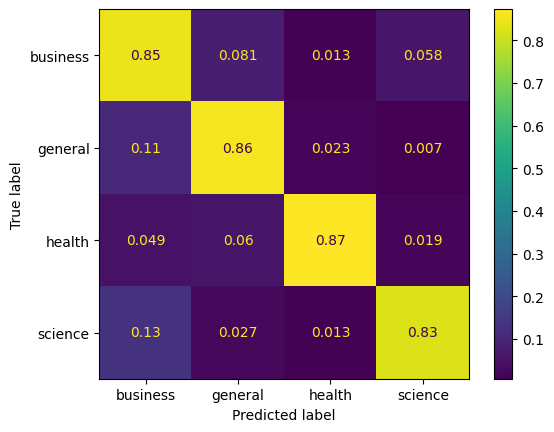

In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, ConfusionMatrixDisplay

#load train data
df = pd.read_csv("./google_news_training_ground_truth.csv")
#df = df.groupby("label").head(100) #test 

df = df[["text", "label"]].copy()
df = df.dropna()

X = df["text"]
y = df["label"]

#stratified split keeps class proportions similar in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y
)#random_state=24,

#define the classifier
pipe = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        analyzer="char_wb",
        ngram_range=(3, 5),
        min_df=2
    )),
    ("log_reg_classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

#train
pipe.fit(X_train, y_train)

#predict
y_pred = pipe.predict(X_test)

#evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))

print("\nClassification report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=pipe.classes_, normalize="true")
print("\nConfusion matrix:")
print(cm)
print("Labels:", pipe.classes_)

matrix_display = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=pipe.classes_)
matrix_display.plot()

If needed for later, dump the trained classifier 

In [ ]:
#for exporting the classifier to a pkl file
import joblib

joblib.dump(pipe, 'trained_classifier.pkl', compress=True) 

['trained_classifie.pkl']

If interested, the wrong predicitons of the classifier can be printed here

In [ ]:
results = pd.DataFrame({
    "text": X_test,
    "true": y_test,
    "pred": y_pred
})

wrong = results[results["true"] != results["pred"]]
print(wrong.to_string())

kfold cross validation 

In [2]:
#n-fold cross validation for a more representative evaluation of the classifier, the Macro-F1 is of specal interest here since the classes 
#in the train data are skewed towared gerneal and buisiness
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, f1_score

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scores = cross_validate(
    pipe,
    X,
    y,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "macro_f1": make_scorer(f1_score, average="macro")
    }
)

#print(scores)
print("Accuracy:", scores["test_accuracy"].mean(), "+/-", scores["test_accuracy"].std())
print("Macro F1:", scores["test_macro_f1"].mean(), "+/-", scores["test_macro_f1"].std())

Accuracy: 0.8513778289773682 +/- 0.018956740492374727
Macro F1: 0.8483783795931199 +/- 0.02150034132274857


Extract the words the calssifier is most sensitive to to build better search queries

In [ ]:
import numpy as np
import pandas as pd

def get_top_queries(pipeline, top_n=20):
    #get learned features from ifidf vectorizer
    tfidf = pipeline.named_steps['tfidf']
    feature_names = np.array(tfidf.get_feature_names_out())
    
    #get coefs. from trained classifier 
    classifier = pipeline.named_steps['log_reg_classifier']
    coefficents = classifier.coef_
    classes = classifier.classes_
    
    query_recomendations = {}
    

    #iterate over categories and get the top_n ngrams
    for i, class_label in enumerate(classes):
    
        #sort by descending
        top_indices = np.argsort(coefficents[i])[-top_n:][::-1]
        
        #get the coresponding ngrams and weights
        top_features = feature_names[top_indices]
        top_weights = coefficents[i][top_indices]
        
        #remove spaces from ngrmas
        cleaned_words = [feat.strip() for feat in top_features if len(feat.strip()) > 2]
        
        #remove douplicates
        unique_words = list(dict.fromkeys(cleaned_words))
        
        query_recomendations[class_label] = unique_words[:10]
        
        print(f"\n=== Top Signal-words for topic: {class_label.upper()} ===")
        for word, weight in zip(top_features[:10], top_weights[:10]):
            print(f"  '{word}' (Influence: +{round(weight, 2)})")
            
    return query_recomendations

In [ ]:
ngrams = get_top_queries(pipe)


=== Top Signal-words for topic: BUSINESS ===
  'uto' (Influence: +1.07)
  'auto' (Influence: +1.07)
  ' vw' (Influence: +1.07)
  'bank' (Influence: +1.02)
  'ktie' (Influence: +0.99)
  'preis' (Influence: +0.97)
  'prei' (Influence: +0.97)
  'aktie' (Influence: +0.96)
  ' us' (Influence: +0.95)
  'aut' (Influence: +0.92)

=== Top Signal-words for topic: GENERAL ===
  ' in ' (Influence: +1.62)
  'afd' (Influence: +1.44)
  ' af' (Influence: +1.42)
  'in ' (Influence: +1.36)
  'er ' (Influence: +1.35)
  ' afd' (Influence: +1.34)
  'pol' (Influence: +1.19)
  ' – ' (Influence: +1.12)
  'oli' (Influence: +1.07)
  'poli' (Influence: +1.04)

=== Top Signal-words for topic: HEALTH ===
  'her' (Influence: +1.27)
  'isik' (Influence: +1.19)
  'risik' (Influence: +1.19)
  'risi' (Influence: +1.17)
  'sik' (Influence: +1.14)
  'isi' (Influence: +1.12)
  'isiko' (Influence: +1.12)
  'siko' (Influence: +1.12)
  'iko' (Influence: +1.12)
  'udie' (Influence: +1.07)

=== Top Signal-words for topic: SCI

In [1]:
import re
from collections import Counter

def ngrams_to_real_words(ngram, alle_titel, top_m=3):
    """searches in the titles for words that contrain the extracted ngrams."""

    clean_ngram = ngram.strip()
    if len(clean_ngram) < 2:
        return []
    
    found_words = []
   
    #regex to isolate words that contrain the ngram
    pattern = re.compile(r'\b\w*' + re.escape(clean_ngram) + r'\w*\b', re.IGNORECASE)
    
    for titel in alle_titel:
        matches = pattern.findall(titel)
        for match in matches:
            if len(match) > len(clean_ngram): #match should be a real word that is longer than the ngram
                found_words.append(match.lower())

 
    haeufigste = [wort for wort, count in Counter(found_words).most_common(top_m)]
    return haeufigste

In [ ]:
for key, value in ngrams.items():
    print(f'========== {key} ==========')
    for v in value:
        output = ngrams_to_real_words(v, alle_titel=df["text"])
        print(v, output)

========== business ==========
uto ['auto', 'autos', 'autoindustrie']
auto ['autos', 'autoindustrie', 'autobauer']
bank ['commerzbank', 'banken', 'notenbank']
ktie ['aktie', 'aktien', 'aktienrückkauf']
preis ['preise', 'goldpreis', 'heizölpreise']
prei ['preise', 'preis', 'goldpreis']
aktie ['aktien', 'aktienrückkauf', 'ölaktien']
aut ['auto', 'laut', 'autos']
kau ['verkauft', 'kaufen', 'kaum']
mark ['marke', 'supermarkt', 'markt']
========== general ==========
afd []
pol ['polizei', 'politiker', 'polizisten']
oli ['polizei', 'politiker', 'polizisten']
poli ['polizei', 'politiker', 'polizisten']
erl ['berlin', 'verletzt', 'verliert']
ahn ['bahn', 'bahnstrecke', 'autobahn']
tte ['unwetter', 'gewitter', 'lebensmittel']
lin ['berlin', 'berliner', 'linke']
itz ['hitze', 'hitzewelle', 'görlitz']
ter ['unter', 'weiter', 'weitere']
========== health ==========
her ['forscher', 'deutscher', 'therapie']
isik ['risiko', 'demenzrisiko', 'risiken']
risik ['risiko', 'demenzrisiko', 'risiken']
risi 